# lyricsLM: build a GPT from scratchCompanion notebook to the article.Runtime > Change runtime type > T4 GPU, then Runtime > Run all.Takes about 10 minutes.

In [2]:
import torch, torch.nn as nn, requests, re, time
from torch.nn import functional as F
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)
if device == 'cpu':
    print('WARNING: no GPU. Go to Runtime > Change runtime type > T4 GPU.')
    print('On CPU this will take hours instead of minutes.')
import matplotlib.pyplot as plt
import json, os, shutil

device: cpu
On CPU this will take hours instead of minutes.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [3]:
PROJECT_DIR = '/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch'

In [1]:
from google.colab import userdata

token = userdata.get('GITHUB_TOKEN')

!git clone -q https://{token}@github.com/parthabiswas1/lyricsLM.git /content/repo
!git -C /content/repo config user.email "biswas_partha@hotmail.com"
!git -C /content/repo config user.name "Partha Biswas"
!mkdir -p /content/repo/notebook /content/repo/frontend

## 1. Get the songbooks

In [4]:
BOOKS = {
    # ---- Indian poets, about 30% of the corpus ----
    'tagore_gitanjali':     7164,   # song offerings, the Nobel book
    'tagore_gardener':      6686,   # love poems
    'tagore_stray_birds':   6524,   # short aphorisms
    'tagore_fruit':         6522,   # Fruit-Gathering
    'tagore_crescent':      6520,   # The Crescent Moon
    'tagore_fugitive':      7971,   # The Fugitive
    'kabir_songs':          6519,   # Songs of Kabir, Tagore's translation
    'indian_anthology':    74751,   # Anthology of Modern Indian Poetry
    'naidu_threshold':       680,   # Sarojini Naidu

    # ---- Western poets, about 70% ----
    'dickinson':           12242,   # Poems, Three Series, Complete
    'poe':                 10031,   # Complete Poetical Works
    'frost_new_hampshire': 58611,   # 1923, contains our seed line
    'blake_songs':          1934,   # Songs of Innocence and of Experience
    'keats_1820':          23684,   # Poems Published in 1820
    'wordsworth':           8774,   # Poems in Two Volumes, Volume 1
    'wordsworth_tennyson': 14952,   # Selections
}
# Frost is public domain in the US. Outside the US he is in copyright
# until 2034, so delete that line if you are elsewhere.
# Do NOT add Shelley #4800 without reading the balance section: it is
# larger than everything above combined.

URL_PATTERNS = [
    'https://www.gutenberg.org/ebooks/{id}.txt.utf-8',
    'https://www.gutenberg.org/files/{id}/{id}-0.txt',
    'https://www.gutenberg.org/files/{id}/{id}.txt',
    'https://www.gutenberg.org/cache/epub/{id}/pg{id}.txt',
]
HEADERS = {'User-Agent': 'Mozilla/5.0 (compatible; lyricsLM-tutorial/1.0)'}

def fetch(book_id):
    for pattern in URL_PATTERNS:
        url = pattern.format(id=book_id)
        try:
            r = requests.get(url, headers=HEADERS, timeout=30)
            if r.status_code == 200 and len(r.text) > 5000:
                return r.text
        except Exception:
            pass
        time.sleep(1)
    raise RuntimeError(f'could not download book {book_id}')

raw = {}
for name, bid in BOOKS.items():
    raw[name] = fetch(bid)
    print(f'{name:24s} {len(raw[name]):>9,} chars')

tagore_gitanjali            97,888 chars
tagore_gardener             98,389 chars
tagore_stray_birds          51,545 chars
tagore_fruit                76,531 chars
tagore_crescent             67,836 chars
tagore_fugitive            131,550 chars
kabir_songs                119,004 chars
indian_anthology           147,642 chars
naidu_threshold             68,799 chars
dickinson                  206,658 chars
poe                        408,298 chars
frost_new_hampshire        136,813 chars
blake_songs                 52,343 chars
keats_1820                 277,708 chars
wordsworth                 111,878 chars
wordsworth_tennyson        276,289 chars


## 2. Clean it

In [5]:
def clean(text):
    # Cut the tail FIRST. Cutting the head first shifts every position,
    # which would make the end position point to the wrong place.
    end = re.search(r'\*\*\*\s*END OF (THE|THIS) PROJECT GUTENBERG.*?\*\*\*', text, re.S | re.I)
    if end:   text = text[:end.start()]
    start = re.search(r'\*\*\*\s*START OF (THE|THIS) PROJECT GUTENBERG.*?\*\*\*', text, re.S | re.I)
    if start: text = text[start.end():]

    text = text.replace('\r\n', '\n')
    text = re.sub(r'\n{3,}', '\n\n', text)
    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    return text.strip()

cleaned = {n: clean(t) for n, t in raw.items()}
corpus = '\n\n'.join(cleaned.values())
print(f'{len(corpus):,} characters')
print()
print('--- your real numbers ---')
print('characters per step :', 128*64)
print('steps for one pass  :', round(len(corpus)/(128*64)))
print('5000 steps          :', round(5000/(len(corpus)/(128*64))), 'passes')
print()
print(corpus[:400])

print()
print('BALANCE  (no single book should be far above 25%)')
for name, txt in sorted(cleaned.items(), key=lambda kv: -len(kv[1])):
    share = len(txt)/len(corpus)*100
    flag = '   <-- too big' if share > 25 else ''
    print(f'  {name:24s} {share:5.1f}%{flag}')
indian = sum(len(t) for n,t in cleaned.items()
             if n.startswith(('tagore','kabir','indian','naidu')))
print(f'  Indian poets combined  {indian/len(corpus)*100:.0f}%')

1,863,246 characters

--- your real numbers ---
characters per step : 8192
steps for one pass  : 227
5000 steps          : 22 passes

Gitanjali

Song Offerings

by Rabindranath Tagore

A collection of prose translations made by the author from the original
Bengali

With an introduction by
W. B. YEATS

TO
WILLIAM ROTHENSTEIN

INTRODUCTION

A few days ago I said to a distinguished Bengali doctor of medicine, I
know no German, yet if a translation of a German poet had moved me, I
would go to the British Museum and find books in Eng

BALANCE  (no single book should be far above 25%)
  poe                       19.1%
  wordsworth_tennyson       12.9%
  keats_1820                12.8%
  dickinson                  9.3%
  indian_anthology           5.9%
  tagore_fugitive            5.8%
  frost_new_hampshire        5.7%
  kabir_songs                5.0%
  wordsworth                 4.5%
  tagore_gitanjali           4.0%
  tagore_gardener            3.9%
  tagore_fruit               2.9%
  naid

## 3. Tokenize

In [6]:
chars = sorted(set(corpus))
vocab_size = len(chars)
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for i, c in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda nums: ''.join(itos[i] for i in nums)

print('vocab size:', vocab_size)
print(encode('miles to go'))
print(decode(encode('miles to go')))

vocab size: 85
[71, 67, 70, 63, 77, 1, 78, 73, 1, 65, 73]
miles to go


## 4. Batches

In [7]:
block_size = 128
batch_size = 64
n_embd = 192
n_head = 6
n_layer = 6
dropout = 0.2
learning_rate = 3e-4
max_steps = 5000

data = torch.tensor(encode(corpus), dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]

def get_batch(split):
    d = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - block_size - 1, (batch_size,))
    x = torch.stack([d[i:i+block_size] for i in ix])
    y = torch.stack([d[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

xb, yb = get_batch('train')
print(xb.shape, yb.shape)

torch.Size([64, 128]) torch.Size([64, 128])


## 5. Attention

In [8]:
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k, q = self.key(x), self.query(x)
        w = q @ k.transpose(-2, -1) * k.shape[-1] ** -0.5
        w = w.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        w = F.softmax(w, dim=-1)
        w = self.dropout(w)
        return w @ self.value(x)

class MultiHead(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))

## 6. Block and model

In [9]:
class FeedForward(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd), nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd), nn.Dropout(dropout))
    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self):
        super().__init__()
        self.sa  = MultiHead(n_head, n_embd // n_head)
        self.ff  = FeedForward()
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)
    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x

class LyricsLM(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding    = nn.Embedding(vocab_size, n_embd)
        self.position_embedding = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block() for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok = self.token_embedding(idx)
        pos = self.position_embedding(torch.arange(T, device=idx.device))
        x = self.blocks(tok + pos)
        x = self.ln_f(x)
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(B*T, -1), targets.view(B*T))
        return logits, loss

model = LyricsLM().to(device)
print(f'{sum(p.numel() for p in model.parameters()):,} parameters')

2,723,413 parameters


## 7. Train

In [10]:
@torch.no_grad()
def estimate_loss(iters=50):
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(iters)
        for k in range(iters):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
history = []

torch.save(model.state_dict(), 'checkpoint_0.pt')

for step in range(max_steps):
    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if step % 500 == 0:
        l = estimate_loss()
        history.append((step, l['train'], l['val']))
        print(f"step {step:5d} | train {l['train']:.4f} | val {l['val']:.4f}")

    if step == 1500:
        torch.save(model.state_dict(), 'checkpoint_1500.pt')

torch.save(model.state_dict(), 'checkpoint_final.pt')
print('done')

step     0 | train 4.1451 | val 4.1480
step   500 | train 2.2265 | val 2.3357
step  1000 | train 1.9492 | val 2.0742
step  1500 | train 1.8084 | val 1.9370
step  2000 | train 1.7213 | val 1.8623
step  2500 | train 1.6620 | val 1.8068
step  3000 | train 1.6171 | val 1.7732
step  3500 | train 1.5756 | val 1.7336
step  4000 | train 1.5527 | val 1.7073
step  4500 | train 1.5184 | val 1.6819
done


## 8. The loss curve

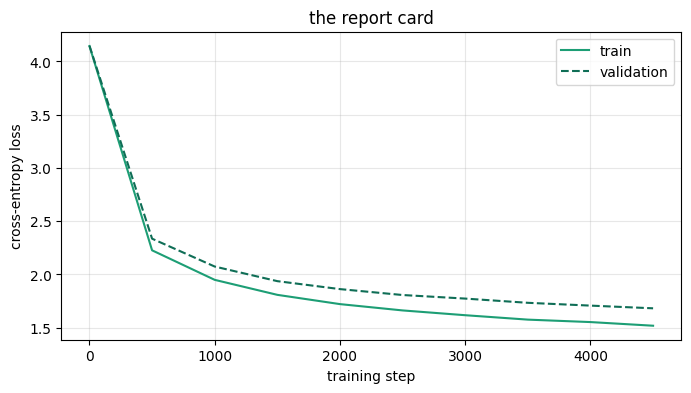

In [11]:

steps = [h[0] for h in history]
plt.figure(figsize=(8,4))
plt.plot(steps, [h[1] for h in history], label='train', color='#1D9E75')
plt.plot(steps, [h[2] for h in history], label='validation', color='#0F6E56', linestyle='--')
plt.xlabel('training step'); plt.ylabel('cross-entropy loss')
plt.title('the report card'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 9. Generate

In [12]:
@torch.no_grad()
def generate(model, seed, max_new_tokens=300, temperature=0.8):
    model.eval()
    idx = torch.tensor([encode(seed)], dtype=torch.long, device=device)
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -block_size:]
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :] / temperature
        probs = F.softmax(logits, dim=-1)
        nxt = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, nxt), dim=1)
    return decode(idx[0].tolist())

print(generate(model, 'and miles to go before I sleep'))

and miles to go before I sleep my fair,
 And silver their -- life, and there, I can seemed from a close
 had doped to-day and peep, and the creatures of Joydan.
 Like up away the secret of sun his desprint Marched, and bu seem
 Thou art thou art and made.
 The richer waiting a street carner that day
 When repressed the way refer


## 10. The reveal: three checkpoints, one seed

In [13]:
seed = 'and miles to go before I sleep'   # <-- put your own line here

for name, path in [('baby', 'checkpoint_0.pt'),
                   ('halfway', 'checkpoint_1500.pt'),
                   ('fully trained', 'checkpoint_final.pt')]:
    model.load_state_dict(torch.load(path))
    print(f'\n===== {name} =====')
    print(generate(model, seed, max_new_tokens=200))


===== baby =====
and miles to go before I sleepd]*4wC9SK9NXf BfE3r[9+D1]niHXjj,D+Nd50R)gPxHtk1n.&P2Bt ]n6;aa]Rv17qieheLFxn4aDQYy5+L"7Z,XF3W7VI(0kpt9jrV*Fi/Q:p
DPaBBLR*jyjMG8Ix9zoN0AggVn'beTe
28w;]a/0USea pdGS0VC4dPLgUuuT/;4 TdpUwmoT4K,U_
GErTHMeW5

===== halfway =====
and miles to go before I sleep in etrace thought
the most in through the moon you a sall of thy of monstily of the pleasurions of
atcanguty of a with the pain; and duch her?

Not were to the say of the trender of Seen keepheres of

===== fully trained =====
and miles to go before I sleep and buy the
serense and say against the heart of silver, Lover, and the child, "When to
equirted at the soul have laughter, quietiles of the brace never of face. We waves I
truthed away intenting for


## 11. Play with the creativity dial

In [14]:
# Make sure we're generating from the fully trained model
model.load_state_dict(torch.load('checkpoint_final.pt'))

for t in [0.4, 0.8, 1.2]:
    print(f'\n--- temperature {t} ---')
    print(generate(model, 'the night is deep', max_new_tokens=150, temperature=t))


--- temperature 0.4 ---
the night is deep of his fairy poems
 And beauty for the carried of the child hand,
 And where the water the been of the burden spring.
 I will the strange and said th

--- temperature 0.8 ---
the night is deeping under my door propers.

 I cannot the sweet in a deep within I'll spring and delight
 Hearly or my in the day house,
 Where it was laughed the ser

--- temperature 1.2 ---
the night is deep.
 To your touch fade, -- the unkning of taled?
 It each faither, threasure, thoughout, the mind Wine of
 the Sen
 Tiges, Voicens anoother. Then booki


## 12. Export the weights for the browser

The three checkpoints on disk right now are PyTorch `.pt` files — a browser cannot read those.
This cell exports each checkpoint's numbers as a flat `float32` binary file plus a small JSON
manifest describing the shape of every tensor, and a `config.json` with the vocabulary and
architecture settings the front end needs. No PyTorch required on the browser side, ever.

Run this cell after training finishes, then download **lyricsLM_web_weights.zip** from the
Colab file browser (folder icon on the left) and follow the front end's README to install it.

In [15]:
def export_checkpoint(path, out_dir, name):
    os.makedirs(out_dir, exist_ok=True)
    state = torch.load(path, map_location='cpu')
    manifest = []
    offset = 0
    bin_path = os.path.join(out_dir, f'{name}.bin')
    with open(bin_path, 'wb') as f:
        for key, tensor in state.items():
            arr = tensor.detach().cpu().to(torch.float32).numpy()
            f.write(arr.tobytes())
            manifest.append({
                'name': key,
                'shape': list(arr.shape),
                'offset': offset,
                'length': int(arr.size),
            })
            offset += int(arr.size)
    with open(os.path.join(out_dir, f'{name}.manifest.json'), 'w') as f:
        json.dump(manifest, f)
    print(f'  {name:10s} {offset:>10,} floats  ->  {bin_path}  ({offset*4/1e6:.1f} MB)')

# Checkpoints were saved locally during training (fast disk I/O).
# The export itself is written straight to Drive so it survives a runtime reset.
EXPORT_DIR = os.path.join(PROJECT_DIR, 'web_weights')
print('Exporting checkpoints:')
export_checkpoint('checkpoint_0.pt',     EXPORT_DIR, 'baby')
export_checkpoint('checkpoint_1500.pt',  EXPORT_DIR, 'halfway')
export_checkpoint('checkpoint_final.pt', EXPORT_DIR, 'trained')

config = {
    'vocab_size': vocab_size,
    'n_embd': n_embd,
    'n_head': n_head,
    'n_layer': n_layer,
    'block_size': block_size,
    'stoi': stoi,
    'itos': {str(k): v for k, v in itos.items()},
}
with open(os.path.join(EXPORT_DIR, 'config.json'), 'w') as f:
    json.dump(config, f)
print('\n  config.json written (vocab size', vocab_size, ')')

zip_path = shutil.make_archive(os.path.join(PROJECT_DIR, 'lyricsLM_web_weights'), 'zip', EXPORT_DIR)
print(f'\nZipped to {zip_path}')

Exporting checkpoints:
  baby        3,313,237 floats  ->  /content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/web_weights/baby.bin  (13.3 MB)
  halfway     3,313,237 floats  ->  /content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/web_weights/halfway.bin  (13.3 MB)
  trained     3,313,237 floats  ->  /content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/web_weights/trained.bin  (13.3 MB)

  config.json written (vocab size 85 )

Zipped to /content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/lyricsLM_web_weights.zip


In [16]:
!find "/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch" -iname "*lyricsLM*" 2>/dev/null
!find "/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch" -iname "*.zip" 2>/dev/null

/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch
/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/lyricsLM_with_export_fixed.ipynb
/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/lyricsLM_with_export.ipynb
/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/lyricsLM_web_weights.zip
/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/lyricsLM_web_weights.zip


In [1]:
!cp "/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/lyricsLM.ipynb" /content/repo/notebook/lyricsLM.ipynb

cp: cannot stat '/content/drive/MyDrive/LyricsLM - Build GPT LM from scratch/lyricsLM.ipynb': No such file or directory
